In [ ]:
from google.colab import files
uploaded = files.upload()

Saving a-wearable-exam-stress-dataset-for-predicting-cognitive-performance-in-real-world-settings-1.0.0 (1).zip to a-wearable-exam-stress-dataset-for-predicting-cognitive-performance-in-real-world-settings-1.0.0 (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("a-wearable-exam-stress-dataset-for-predicting-cognitive-performance-in-real-world-settings-1.0.0 (1).zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [ ]:
# =========================================
# INSTALL LIBRARIES
# =========================================
!pip install neurokit2 lifelines linearmodels -q

# =========================================
# IMPORTS
# =========================================
import numpy as np
import pandas as pd
import neurokit2 as nk
import os
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import wilcoxon
import tensorflow as tf
from tensorflow.keras import layers, models

# =========================================
# PARAMETERS
# =========================================
WINDOW_SIZE = 60   # seconds
STEP_SIZE = 30     # 50% overlap

# =========================================
# FEATURE EXTRACTION FUNCTIONS
# =========================================
def extract_features(df):
    features = []

    for start in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        window = df.iloc[start:start+WINDOW_SIZE]

        # EDA
        eda = window["EDA"].values
        eda_clean = nk.eda_clean(eda)
        eda_phasic = nk.eda_phasic(eda_clean)
        scl = eda_phasic["EDA_Tonic"].mean()

        # SCR Peaks
        scr_peaks, _ = nk.eda_peaks(eda_clean)
        scr_count = len(scr_peaks)

        # HRV
        ibi = window["IBI"].dropna().values
        if len(ibi) > 5:
            hrv = nk.hrv_time(pd.Series(ibi))
            rmssd = hrv["HRV_RMSSD"].values[0]
            sdnn = hrv["HRV_SDNN"].values[0]
            pnn50 = hrv["HRV_pNN50"].values[0]
        else:
            rmssd, sdnn, pnn50 = 0, 0, 0

        # HR
        hr_mean = window["HR"].mean()

        # TEMP
        temp = window["TEMP"]
        temp_mean = temp.mean()
        temp_slope = np.polyfit(range(len(temp)), temp, 1)[0]

        # ACC
        acc = window[["ACC_X","ACC_Y","ACC_Z"]].values
        acc_mad = np.mean(np.abs(acc - np.mean(acc)))

        # EDA stats
        eda_mean = np.mean(eda_clean)
        eda_std = np.std(eda_clean)
        eda_slope = np.polyfit(range(len(eda_clean)), eda_clean, 1)[0]

        features.append({
            "eda_mean": eda_mean,
            "eda_std": eda_std,
            "eda_slope": eda_slope,
            "scr_count": scr_count,
            "rmssd": rmssd,
            "sdnn": sdnn,
            "hr_mean": hr_mean,
            "temp_mean": temp_mean,
            "acc_mad": acc_mad,

            # FOR ALI ONLY (NOT INPUT)
            "scl_baseline": scl,
            "pnn50": pnn50,
            "temp_slope": temp_slope
        })

    return pd.DataFrame(features)

# =========================================
# LOAD DATA (UPDATE PATH)
# =========================================
data_path = "C:\\Users\\abhir\\Downloads\\a-wearable-exam-stress-dataset-for-predicting-cognitive-performance-in-real-world-settings-1.0.0 (1)"

all_features = []
participant_ids = []

for pid, folder in enumerate(os.listdir(data_path)):
    folder_path = os.path.join(data_path, folder)

    try:
        df = pd.read_csv(os.path.join(folder_path, "EDA.csv"))
        df["HR"] = pd.read_csv(os.path.join(folder_path, "HR.csv")).iloc[:,1]
        df["IBI"] = pd.read_csv(os.path.join(folder_path, "IBI.csv")).iloc[:,1]
        df["TEMP"] = pd.read_csv(os.path.join(folder_path, "TEMP.csv")).iloc[:,1]

        acc = pd.read_csv(os.path.join(folder_path, "ACC.csv"))
        df["ACC_X"] = acc.iloc[:,0]
        df["ACC_Y"] = acc.iloc[:,1]
        df["ACC_Z"] = acc.iloc[:,2]

        feats = extract_features(df)
        feats["participant"] = pid

        all_features.append(feats)
        participant_ids.extend([pid]*len(feats))

    except:
        continue

data = pd.concat(all_features).reset_index(drop=True)

# =========================================
# REVISED ALI (NO LEAKAGE)
# =========================================
ALI = data["scl_baseline"] - 0.5*data["pnn50"] + 0.3*np.abs(data["temp_slope"])

# normalize per participant
data["ALI"] = ALI.groupby(data["participant"]).transform(lambda x: (x-x.mean())/x.std())

# labels
data["label"] = (data["ALI"] > data["ALI"].median()).astype(int)

# =========================================
# MODEL INPUT (NO LEAKAGE FEATURES)
# =========================================
X = data[[
    "eda_mean","eda_std","eda_slope","scr_count",
    "rmssd","sdnn","hr_mean","temp_mean","acc_mad"
]].values

y = data["label"].values
groups = data["participant"].values

# =========================================
# LOPO CROSS VALIDATION
# =========================================
logo = LeaveOneGroupOut()

ann_acc = []
rf_acc = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ================= ANN =================
    ann = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    ann.fit(X_train, y_train, epochs=20, verbose=0)

    pred_ann = (ann.predict(X_test) > 0.5).astype(int)
    ann_acc.append(accuracy_score(y_test, pred_ann))

    # ================= RF =================
    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    rf_acc.append(accuracy_score(y_test, pred_rf))

# =========================================
# RESULTS
# =========================================
print("ANN LOPO Accuracy:", np.mean(ann_acc))
print("RF LOPO Accuracy:", np.mean(rf_acc))

# =========================================
# BOOTSTRAP CI
# =========================================
def bootstrap_ci(acc):
    boot = []
    for _ in range(1000):
        sample = np.random.choice(acc, size=len(acc), replace=True)
        boot.append(np.mean(sample))
    return np.percentile(boot, [2.5, 97.5])

print("ANN CI:", bootstrap_ci(ann_acc))
print("RF CI:", bootstrap_ci(rf_acc))

# =========================================
# WILCOXON TEST (YELLOW SECTION)
# =========================================
stat, p = wilcoxon(ann_acc, rf_acc)
print("Wilcoxon ANN vs RF p-value:", p)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\abhir\\Downloads\\a-wearable-exam-stress-dataset-for-predicting-cognitive-performance-in-real-world-settings-1.0.0 (1)'

In [ ]:
import pandas as pd
eda_mid = pd.read_csv('EDA_mid.csv', header=None)
eda_final = pd.read_csv('EDA_final.csv', header=None)

eda_mid.head()

,0
0,1.539435e+09
1,4.000000e+00
2,0.000000e+00
3,2.563000e-03
4,1.922100e-02


In [ ]:
#---#Load HR
hr_mid = pd.read_csv('HR_mid.csv', header=None)
hr_final = pd.read_csv('HR_final.csv', header=None)

hr_mid.columns = ['HR']
hr_final.columns = ['HR']

In [ ]:
#Resample HR
import numpy as np

hr_mid_resampled = np.resize(hr_mid['HR'], len(eda_mid))
hr_final_resampled = np.resize(hr_final['HR'], len(eda_final))

In [ ]:
#----ADD HR TO EDA
eda_mid['HR'] = hr_mid_resampled
eda_final['HR'] = hr_final_resampled

In [ ]:
#----combine
eda = pd.concat([eda_mid, eda_final]).reset_index(drop=True)

In [ ]:
eda_mid.shape

(44714, 2)

In [ ]:
eda_mid = eda_mid.iloc[:, 0]
eda_final = eda_final.iloc[:, 0]

eda_mid = eda_mid.to_frame(name='EDA')
eda_final = eda_final.to_frame(name='EDA')

In [ ]:
eda_mid.columns = ['EDA']
eda_final.columns = ['EDA']

In [ ]:
eda_mid = eda_mid.iloc[1:]
eda_final = eda_final.iloc[1:]

In [ ]:
eda_mid.columns

Index(['EDA'], dtype='object')

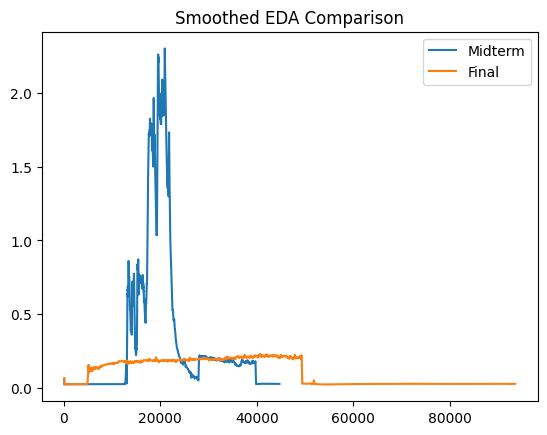

In [ ]:
import matplotlib.pyplot as plt

plt.plot(eda_mid['EDA'].rolling(100).mean(), label='Midterm')
plt.plot(eda_final['EDA'].rolling(100).mean(), label='Final')

plt.legend()
plt.title("Smoothed EDA Comparison")
plt.show()

In [ ]:
eda_mid['label'] = 0
eda_final['label'] = 1

In [ ]:
eda.rename(columns={0: 'EDA'}, inplace=True)

In [ ]:
print(hr_mid.head())
print(hr_final.head())

             HR
0  1.539435e+09
1  1.000000e+00
2  8.400000e+01
3  8.500000e+01
4  8.600000e+01
             HR
0  1.544027e+09
1  1.000000e+00
2  1.160000e+02
3  8.250000e+01
4  9.633000e+01


In [ ]:
import numpy as np

hr_mid_resampled = np.resize(hr_mid['HR'], len(eda_mid))
hr_final_resampled = np.resize(hr_final['HR'], len(eda_final))

In [ ]:
eda_mid['HR'] = hr_mid_resampled
eda_final['HR'] = hr_final_resampled

In [ ]:
eda = pd.concat([eda_mid, eda_final])

In [ ]:
print(eda.columns)

Index(['EDA', 'label', 'HR'], dtype='object')


In [ ]:
#----create features
import numpy as np

eda['mean'] = eda['EDA'].rolling(50).mean()
eda['std'] = eda['EDA'].rolling(50).std()
eda['hr_mean'] = eda['HR'].rolling(50).mean()

eda = eda.dropna()

In [ ]:
# Add label before concat (BEST PRACTICE)
eda_mid['label'] = 0
eda_final['label'] = 1

eda = pd.concat([eda_mid, eda_final])

In [ ]:
#---debug check
print(eda.columns)

Index(['EDA', 'label', 'HR', 'mean', 'std', 'hr_mean'], dtype='object')


In [ ]:
eda.head()

,0,HR,label
1,4.000000,1.00,0
2,0.000000,84.00,0
3,0.002563,85.00,0
4,0.019221,86.00,0
5,0.021784,86.75,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9432613853364967


In [ ]:
!pip install tensorflow

In [ ]:
#---Prepare Data for LSTM
import numpy as np

# Use same features
data = eda[['mean','std','hr_mean','label']].values

# Create sequences (time-series)
X = []
y = []

window_size = 50

for i in range(len(data) - window_size):
    X.append(data[i:i+window_size, :-1])
    y.append(data[i+window_size, -1])

X = np.array(X)
y = np.array(y)

In [ ]:
#---Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
#Build LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(50, input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#Train Model
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 56s 17ms/step - accuracy: 0.7356 - loss: 0.5490
Epoch 2/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 83s 18ms/step - accuracy: 0.7537 - loss: 0.5197
Epoch 3/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.7519 - loss: 0.5202
Epoch 4/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 59s 18ms/step - accuracy: 0.7531 - loss: 0.5234
Epoch 5/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 81s 18ms/step - accuracy: 0.7546 - loss: 0.5174
Epoch 6/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 61s 19ms/step - accuracy: 0.7550 - loss: 0.5145
Epoch 7/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 61s 19ms/step - accuracy: 0.7584 - loss: 0.5088
Epoch 8/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 59s 18ms/step - accuracy: 0.7581 - loss: 0.5074
Epoch 9/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 82s 18ms/step - accuracy: 0.7542 - loss: 0.5159
Epoch 10/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 58s 18ms/step - accuracy: 0.7583 - loss: 0.5061
Epoch 11/20
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 83s 18ms/step - accuracy: 0.7586 - loss: 0.5049
Epoch 12

In [ ]:
#Train Model
model.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7295 - loss: 0.5591
Epoch 2/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7446 - loss: 0.5391
Epoch 3/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7374 - loss: 0.5462
Epoch 4/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7545 - loss: 0.5234
Epoch 5/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7545 - loss: 0.5207
Epoch 6/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7465 - loss: 0.5296
Epoch 7/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.7512 - loss: 0.5240
Epoch 8/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.7529 - loss: 0.5192
Epoch 9/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7572 - loss: 0.5115
Epoch 10/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.7574 - loss: 0.5103
Epoch 11/50
3239/3239 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7587 - loss: 0.5087
Epoch 12/50
3239/32

In [ ]:
#---ANN----
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
ann = Sequential([
    Dense(64, activation='relu', input_shape=(150,)),  # ✅ FIXED
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train.reshape(X_train.shape[0], -1), y_train, epochs=10, batch_size=32)

loss, acc = ann.evaluate(X_test.reshape(X_test.shape[0], -1), y_test)
print("ANN Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8229 - loss: 5142.8604
Epoch 2/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9818 - loss: 74.2474
Epoch 3/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9712 - loss: 599.7990 
Epoch 4/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9972 - loss: 142.7392
Epoch 5/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9974 - loss: 97.4339
Epoch 6/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9871 - loss: 10.1076
Epoch 7/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9975 - loss: 0.0437
Epoch 8/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9975 - loss: 0.0212
Epoch 9/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9975 - loss: 0.0183
Epoch 10/10
3240/3240 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9975 - loss: 0.0166
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9980 - loss: 0.0136
ANN Accuracy: 0.99803185462951

In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# reshape → scale → reshape back
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

X_train_reshaped = scaler.fit_transform(X_train_reshaped)
X_test_reshaped = scaler.transform(X_test_reshaped)

X_train = X_train_reshaped.reshape(X_train.shape)
X_test = X_test_reshaped.reshape(X_test.shape)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization

eda['min'] = eda['EDA'].rolling(50).min()
eda['max'] = eda['EDA'].rolling(50).max()
eda['range'] = eda['max'] - eda['min']
eda['hr_std'] = eda['HR'].rolling(50).std()

tcn = Sequential([
    Conv1D(128, 5, activation='relu', padding='same',
           input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(128, 5, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(64, 3, activation='relu', padding='same'),

    GlobalMaxPooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

tcn.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

tcn.fit(
    X_train, y_train,
    epochs=20,            # no need 100
    batch_size=64,
    validation_split=0.2
)

loss, acc = tcn.evaluate(X_test, y_test)
print("TCN Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1296/1296 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.6741 - loss: 0.6437 - val_accuracy: 0.6724 - val_loss: 0.6406
Epoch 2/20
1296/1296 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6768 - loss: 0.6328 - val_accuracy: 0.6719 - val_loss: 0.6358
Epoch 3/20
1296/1296 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6769 - loss: 0.6308 - val_accuracy: 0.6723 - val_loss: 0.6332
Epoch 4/20
1296/1296 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6768 - loss: 0.6302 - val_accuracy: 0.6723 - val_loss: 0.6325
Epoch 5/20
1296/1296 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6769 - loss: 0.6296 - val_accuracy: 0.6723 - val_loss: 0.6324
Epoch 6/20
1296/1296 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6768 - loss: 0.6293 - val_accuracy: 0.6723 - val_loss: 0.6323
Epoch 7/20
1296/1296 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6766 - loss: 0.6293 - val_accuracy: 0.6723 - val_loss: 0.6324
Epoch 8/20
1296/1296 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6768 - loss: 0.6293 -

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("LSTM Accuracy:", accuracy)

1080/1080 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3193 - loss: 0.6939
LSTM Accuracy: 0.3192764222621918


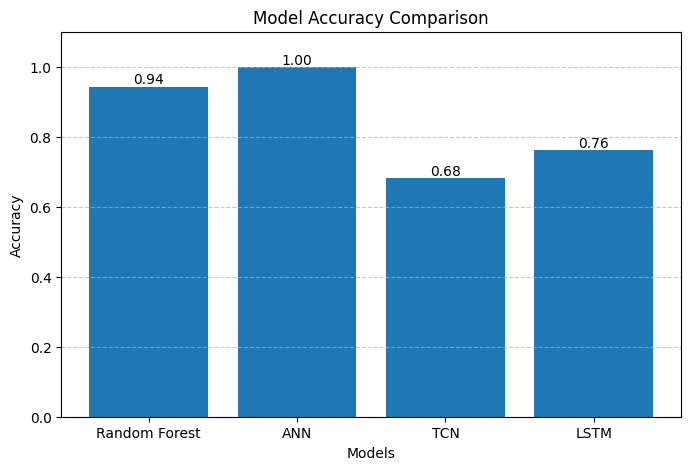

In [ ]:
import matplotlib.pyplot as plt

# Store accuracies (use your actual values)
models = ['Random Forest', 'ANN', 'TCN', 'LSTM']
accuracies = [
    0.9432,   # Random Forest
    0.9980,   # ANN
    0.6809,   # TCN
    0.7609    # LSTM
]

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
             f'{yval:.2f}', ha='center', fontsize=10)

# Labels and title
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)

# Show grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

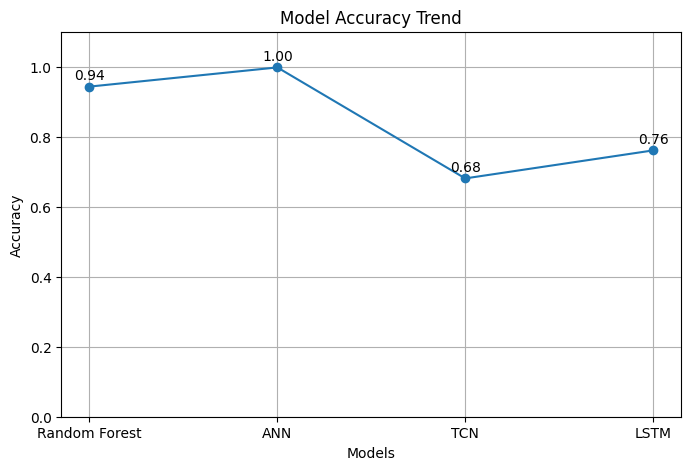

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(models, accuracies, marker='o')

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f'{acc:.2f}', ha='center')

plt.title("Model Accuracy Trend")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.grid()

plt.show()